In [19]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [20]:
insurance_data=pd.read_csv("insurance.csv")

In [21]:
#INTERACTION FEATURES
X=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]

X=pd.get_dummies(X,columns=["region"],drop_first=True,dtype=int)

X["sex"]=X["sex"].map({"female":1,"male":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})

X["age_smoker"]=X["age"]*X["smoker"]
X["bmi_smoker"]=X["bmi"]*X["smoker"]

In [22]:
X_train, X_test,y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model=LinearRegression()

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

r2=r2_score(y_test,y_pred)
print("r-squared:",r2)

r-squared: 0.865231697953168


MSE for alphas=0.001 20922599.87103596
MSE for alphas=0.1 20921803.698431373
MSE for alphas=1 20914832.63508914
MSE for alphas=2 20908106.77995452
MSE for alphas=3 20901927.931570217
MSE for alphas=5 20890881.000633497
MSE for alphas=20 20877828.532378826
MSE for alphas=30 20937537.133939773


<Axes: >

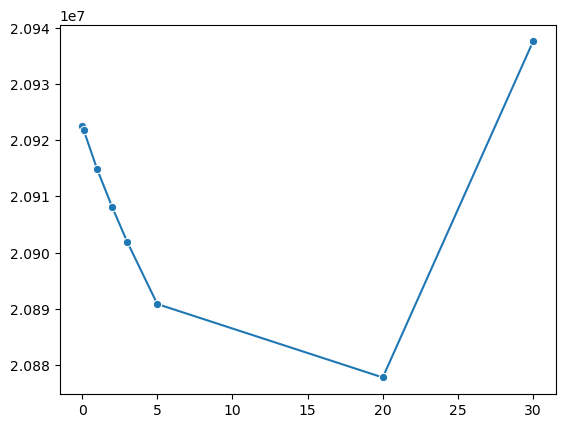

In [26]:
import seaborn as sns
alphas=[0.001,0.1,1,2,3,5,20,30]
mses=[]
for a in alphas:
    lasso_model=Lasso(alpha=a)
    lasso_model.fit(X_train,y_train)

    y_pred=lasso_model.predict(X_test)
    mse=mean_squared_error(y_test,y_pred)
    print(f"MSE for alphas={a}",mse)
    mses.append(mse)
sns.lineplot(x=alphas,y=mses,marker="o")    

In [31]:
#LASSOCV/RIDGECV
from sklearn.linear_model import LassoCV
a=[0.001,0.1,1,2,3,5,20,30]

lasso_cv_model=LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)
lasso_cv_model.fit(X_train,y_train)
print("best alpha:",lasso_cv_model.alpha_)

y_pred=lasso_cv_model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("mse=",mse)
print("r2=",r2)

best alpha: 0.001
mse= 20922599.87103596
r2= 0.8652317499151699
